In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numba
import tqdm
import scipy
import seaborn
import os
import sys
import joblib
from itertools import product
from pathlib import Path

In [11]:
# ==== LaTeX + SVG text mode (Illustrator-safe) ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18*1.5      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5 
plt.rcParams['xtick.labelsize'] = 12*1.5     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5     # legend text


In [3]:
path_to_plot_data = "/home/keerthm/twinfer/figure_3/"
path_to_plots = "/home/keerthm/twinfer/plots_3/"
os.makedirs(path_to_plots, exist_ok=True)

In [19]:
def create_box_plot_and_save(df_results, save_dir):
    """
    Plot 1: Correlations colored by threshold (blue > threshold, red < threshold, grey in between)
    Plot 2: Threshold boxplots in grey
    """
    
    # ==========================================
    # PLOT 1: CORRELATIONS WITH THRESHOLD-BASED COLORS
    # ==========================================
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # REMOVE ALL BACKGROUNDS
    fig.patch.set_facecolor('none')  # Figure background transparent
    ax.set_facecolor('none')         # Axes background transparent
    
    conditions = df_results['Condition'].unique()
    
    # Prepare data for each condition
    all_values_12 = []  # gene_1 -> gene_2
    all_values_21 = []  # gene_2 -> gene_1
    all_thresholds_12 = []
    all_thresholds_21 = []
    
    for condition in conditions:
        condition_data = df_results[df_results['Condition'] == condition]
        vals_12 = condition_data['gene_1_to_gene_2'].values.tolist()
        vals_21 = condition_data['gene_2_to_gene_1'].values.tolist()
        thresh_12 = condition_data['threshold_12'].values.tolist()
        thresh_21 = condition_data['threshold_21'].values.tolist()
        
        all_values_12.append(vals_12)
        all_values_21.append(vals_21)
        all_thresholds_12.append(thresh_12)
        all_thresholds_21.append(thresh_21)
    
    # Flatten thresholds for range calculation
    flat_thresholds = [item for sublist in all_thresholds_12 + all_thresholds_21 for item in sublist]
    
    # Add threshold range background
    x_range = np.arange(0.5, len(conditions) + 0.5, 0.01)
    
    # Add threshold lines
    # Add threshold lines
    ax.axhline(np.mean(flat_thresholds),
            linestyle="--",
            color="black",
            linewidth=1,
            alpha=0.7,
            dashes=(12, 4))    # 8pt dash, 4pt gap

    ax.axhline(-np.mean(flat_thresholds),
            linestyle="--",
            color="black",
            linewidth=1,
            alpha=0.7,
            dashes=(12,4))
    
    # Function to determine color based on threshold
    def get_threshold_color(values, thresholds):
        """Determine color based on whether median is above, below, or between thresholds"""
        median_val = np.median(values)
        mean_threshold = np.mean(thresholds)
        
        if median_val > mean_threshold:
            return 'blue'
        elif median_val < -mean_threshold:
            return 'red' 
        else:
            return 'grey'
    
    # Create boxplots for gene_1 -> gene_2
    positions_12 = [i - 0.2 for i in range(1, len(conditions) + 1)]
    box_12 = ax.boxplot(all_values_12, positions=positions_12, patch_artist=True, 
                        showfliers=False, widths=0.3)
    
    # Create boxplots for gene_2 -> gene_1  
    positions_21 = [i + 0.2 for i in range(1, len(conditions) + 1)]
    box_21 = ax.boxplot(all_values_21, positions=positions_21, patch_artist=True, 
                        showfliers=False, widths=0.3)
    solid = mlines.Line2D([], [], color="black", linestyle="-",
                      label=r"$\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$")

    dashed = mlines.Line2D([], [], color="black", linestyle="--",
                        label=r"$\hat{\rho}^{\dagger}_{y(t_{1}) \to x(t_{2})}$")

    ax.legend(handles=[solid, dashed])
    
    # Color gene_1 -> gene_2 boxplots based on threshold (outline only)
    for i, (patch, values, thresholds) in enumerate(zip(box_12['boxes'], all_values_12, all_thresholds_12)):
        color = get_threshold_color(values, thresholds)
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor(color)
        patch.set_linewidth(2)
        patch.set_clip_on(False)
    
    for i, (whisker, values, thresholds) in enumerate(zip(box_12['whiskers'], all_values_12 * 2, all_thresholds_12 * 2)):
        if i < len(all_values_12) * 2:  # Handle whisker indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_12):
                color = get_threshold_color(all_values_12[condition_idx], all_thresholds_12[condition_idx])
                whisker.set_color(color)
                whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    for i, (cap, values, thresholds) in enumerate(zip(box_12['caps'], all_values_12 * 2, all_thresholds_12 * 2)):
        if i < len(all_values_12) * 2:  # Handle cap indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_12):
                color = get_threshold_color(all_values_12[condition_idx], all_thresholds_12[condition_idx])
                cap.set_color(color)
                cap.set_linewidth(2)
        cap.set_clip_on(False)
    
    for i, (median, values, thresholds) in enumerate(zip(box_12['medians'], all_values_12, all_thresholds_12)):
        color = get_threshold_color(values, thresholds)
        median.set_color(color)
        median.set_linewidth(2)
        median.set_clip_on(False)
    
    # Color gene_2 -> gene_1 boxplots based on threshold (outline only)
    for i, (patch, values, thresholds) in enumerate(zip(box_21['boxes'], all_values_21, all_thresholds_21)):
        color = get_threshold_color(values, thresholds)
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor(color)
        patch.set_linestyle("--")
        patch.set_linewidth(2)
        patch.set_clip_on(False)

    for i, (whisker, values, thresholds) in enumerate(zip(box_21['whiskers'], all_values_21 * 2, all_thresholds_21 * 2)):
        if i < len(all_values_21) * 2:  # Handle whisker indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_21):
                color = get_threshold_color(all_values_21[condition_idx], all_thresholds_21[condition_idx])
                whisker.set_color(color)
                whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    for i, (cap, values, thresholds) in enumerate(zip(box_21['caps'], all_values_21 * 2, all_thresholds_21 * 2)):
        if i < len(all_values_21) * 2:  # Handle cap indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_21):
                color = get_threshold_color(all_values_21[condition_idx], all_thresholds_21[condition_idx])
                cap.set_color(color)
                cap.set_linewidth(2)
        cap.set_clip_on(False)
    
    for i, (median, values, thresholds) in enumerate(zip(box_21['medians'], all_values_21, all_thresholds_21)):
        color = get_threshold_color(values, thresholds)
        median.set_color(color)
        median.set_linewidth(2)
        median.set_clip_on(False)
    
    # Set custom tick labels
    folder_names = ["1", "2", "3", "4", "5", "6"]
    ax.set_xticks(range(1, len(conditions) + 1))
    ax.set_xticklabels(folder_names[:len(conditions)], ha="center")
    ax.tick_params(axis='both', which='both', 
                bottom=True, top=False, left=True, right=False,
                labelbottom=True, labelleft=True,
                length=4, width=1)
    plt.ylabel(r"twin cross-correlation")
    plt.savefig(os.path.join(save_dir, 'correlations_with_thresholds.svg'), 
                format='svg', bbox_inches='tight', 
                facecolor='none', edgecolor='none', transparent=True)
    plt.savefig(os.path.join(save_dir, 'correlations_with_thresholds.pdf'), 
                format='pdf', bbox_inches='tight', 
                facecolor='none', edgecolor='none', transparent=True)
    plt.show()
    
    # ==========================================
    # PLOT 2: THRESHOLD BOX PLOTS (GREY)
    # ==========================================
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # REMOVE ALL BACKGROUNDS
    fig.patch.set_facecolor('none')
    ax.set_facecolor('none')
    
    # Create side-by-side boxplots for thresholds
    positions_12 = [i - 0.2 for i in range(1, len(conditions) + 1)]
    box_thresh_12 = ax.boxplot(all_thresholds_12, positions=positions_12, 
                               patch_artist=True, showfliers=True, widths=0.3)
    
    positions_21 = [i + 0.2 for i in range(1, len(conditions) + 1)]
    box_thresh_21 = ax.boxplot(all_thresholds_21, positions=positions_21, 
                               patch_artist=True, showfliers=True, widths=0.3)
    
    # Style all threshold boxplots in grey (outline only)
    for patch in box_thresh_12['boxes']:
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor('grey')
        patch.set_linewidth(2)
        patch.set_clip_on(False)
    
    for whisker in box_thresh_12['whiskers'] + box_thresh_12['caps'] + box_thresh_12['medians']:
        whisker.set_color('grey')
        whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    for patch in box_thresh_21['boxes']:
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor('grey')
        patch.set_linewidth(2)
        patch.set_linestyle("--")
        patch.set_clip_on(False)

    for flier in box_thresh_21['fliers']:
        flier.set_markerfacecolor('grey')
        flier.set_markeredgecolor('grey')
        flier.set_markersize(2)

    for flier in box_thresh_12['fliers']:
        flier.set_markerfacecolor('grey')
        flier.set_markeredgecolor('grey')
        flier.set_markersize(2)

    for whisker in box_thresh_21['whiskers'] + box_thresh_21['caps'] + box_thresh_21['medians']:
        whisker.set_color('grey')
        whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    # Add mean threshold line
    ax.axhline(np.mean(flat_thresholds), linestyle="--", color="black", linewidth=1, alpha=0.7, dashes=(12,4))
    solid = mlines.Line2D([], [], color="black", linestyle="-",
                      label=r"$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$")

    dashed = mlines.Line2D([], [], color="black", linestyle="--",
                        label=r"$\rho^{\dagger}_{y(t_{1}) \to x(t_{2})}$")

    ax.legend(handles=[solid, dashed])
    # Set custom tick labels  
    # folder_names = ["A_B", "A_to_B", "A_to_B_B_to_A", "A_rep_B", "A_rep_B_B_rep_A", "A_rep_B_B_to_A"]
    ax.set_xticks(range(1, len(conditions) + 1))
    ax.set_xticklabels(folder_names[:len(conditions)])
    ax.tick_params(axis='both', which='both', 
                bottom=True, top=False, left=True, right=False,
                labelbottom=True, labelleft=True,
                length=4, width=1)
    plt.ylabel(r"random-pair cross-correlation")
    # Uncomment to save the second plot
    plt.savefig(os.path.join(save_dir, 'threshold_boxplots.svg'), 
                format='svg', bbox_inches='tight',
                facecolor='none', edgecolor='none', transparent=True)
    plt.savefig(os.path.join(save_dir, 'threshold_boxplots.pdf'), 
                format='pdf', bbox_inches='tight',
                facecolor='none', edgecolor='none', transparent=True)
    plt.show()
    
    print(f"Saved plots to {save_dir}:")
    print("1. correlations_with_thresholds.pdf")
    print("2. threshold_boxplots.pdf")
    
    return None

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
import glob
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap


def make_reds_blues_colormap():
    """Custom red–white–blue colormap (white = 0)."""
    reds = plt.cm.Reds(np.linspace(0.8, 0, 64))
    whites = np.ones((1, 4))
    blues = plt.cm.Blues(np.linspace(0, 0.8, 64))
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)


def find_global_correlation_range(data_folder):
    csv_files = glob.glob(str(Path(data_folder) / "*.csv"))
    all_values = []
    for file_path in csv_files:
        if "filtered" in file_path in file_path:
            df = pd.read_csv(file_path, index_col=0)
            arr = df.to_numpy().copy()
            np.fill_diagonal(arr, np.nan)
            masked_matrix = pd.DataFrame(arr, index=df.index, columns=df.columns)
            all_values.extend(masked_matrix.values.flatten())
    all_values = [v for v in all_values if not np.isnan(v)]
    if not all_values:
        raise ValueError("No valid numeric values found in any CSV files")
    return np.min(all_values), np.max(all_values)


def convert_gene_labels(labels, axis='x'):
    converted = []
    for label in labels:
        if label.startswith('gene_'):
            num = int(label.replace('gene_', ''))
            letter = chr(ord('A') + num - 1)
        elif label.startswith('g'):
            num = int(label[1:])
            letter = chr(ord('A') + num - 1)
        else:
            letter = label
        converted.append(
            rf"$\text{{{letter}}}$" if axis == 'x'
            else rf"$\text{{{letter}}}$"
        )


    return converted

def plot_all_correlations_common_scale(
    data_folder, 
    path_to_plots=None, 
    figsize_per_plot=(8, 8), 
    use_symmetric_scale=False,
    matrix_type="correlation"
):
    """
    Plot all correlation matrices.
    • white = 0
    • gray = diagonal
    • transparent background (Illustrator-friendly)
    """

    # --- global scale ---
    global_min, global_max = find_global_correlation_range(data_folder)
    print(f"Global range: {global_min:.3f} → {global_max:.3f}")

    # --- normalization ---
    if use_symmetric_scale:
        max_abs = max(abs(global_min), abs(global_max))
        vmin, vmax = -max_abs, max_abs
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        center = 0
    else:
        vmin, vmax = global_min, global_max
        print(vmin, vmax)
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        center = 0

    cmap = make_reds_blues_colormap()

    csv_files = sorted(glob.glob(str(Path(data_folder) / "*.csv")))

    for file_path in csv_files:
        filename = Path(file_path).stem
        if ("filtered" not in filename):
            continue
        print(f"Processing: {filename}")
        if "five" in filename:
            figsize_per_plot = (9,8)
        else:
            figsize_per_plot = (5,4)

        df = pd.read_csv(file_path, index_col=0)
        data_matrix = df.to_numpy(float)
        # 1. diagonal = gray
        

        # 2. mask the diagonal
        data_matrix = df.to_numpy(float)
        masked_matrix = np.fill_diagonal(data_matrix, np.nan)

        # fig = plt.figure(figsize=figsize_per_plot)
        # gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
        # cbar_ax = fig.add_subplot(gs[0])
        # heatmap_ax = fig.add_subplot(gs[1])
        cmap.set_bad(color="#D9D9D9")
        # # --- draw heatmap ---
        # sns.heatmap(
        #     data_matrix,
        #     ax=heatmap_ax,
        #     cmap=cmap,
        #     norm=norm,
        #     vmin=vmin,
        #     vmax=vmax,
        #     square=True,
        #     cbar=True,
        #     cbar_ax=cbar_ax,
        #     cbar_kws={'orientation': 'vertical', 'label': f'{matrix_type.title()} Value'},
        #     linewidth=1,
        #     linecolor="black",
        #     # center=center
        # )
        

        # # --- labels ---
        # cbar_ax.xaxis.set_label_position('top')
        # cbar_ax.xaxis.tick_top()
        # heatmap_ax.set_xticklabels(convert_gene_labels(df.columns, 'x'))
        # heatmap_ax.set_yticklabels(convert_gene_labels(df.index, 'y'))

        # # --- transparent background ---
        # plt.tight_layout()
        # fig.patch.set_alpha(0)
        fig = plt.figure(figsize=figsize_per_plot)

        # vertical cbar on the left
        gs = fig.add_gridspec(
            1, 2,
            width_ratios=[0.08, 0.92],
            wspace=0.05
        )

        cbar_ax = fig.add_subplot(gs[0])
        heatmap_ax = fig.add_subplot(gs[1])

        sns.heatmap(
            data_matrix,
            ax=heatmap_ax,
            cmap=cmap,
            norm=norm,
            vmin=vmin, vmax=vmax,
            square=True,
            cbar=True,
            cbar_ax=cbar_ax,
            cbar_kws={'orientation': 'vertical', 'label': f'twin cross-correlation'},
            linewidth=1,
            linecolor="black"
        )

        # Style the left-side colorbar
        cbar = heatmap_ax.collections[0].colorbar
        cbar_ax.yaxis.set_ticks_position('left')
        cbar_ax.yaxis.set_label_position('left')
        cbar_ax.yaxis.tick_left()

        for ax in [heatmap_ax, cbar_ax]:
            ax.set_facecolor("none")
        for im in heatmap_ax.get_images() + cbar_ax.get_images():
            im.set_facecolor((1, 1, 1, 0))
            im.set_edgecolor((1, 1, 1, 0))

        # --- save ---
        if path_to_plots:
            out = Path(path_to_plots)
            out.mkdir(parents=True, exist_ok=True)
            png_path = out / f"{filename}_{matrix_type}_with_gridlines.png"
            svg_path = out / f"{filename}_with_gridlines.svg"
            pdf_path = out / f"{filename}_with_gridlines.pdf"

            plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
            fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                        facecolor='none', edgecolor='none', format='svg')
            fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                        facecolor='none', edgecolor='none', format='pdf')
            print(f"Saved PNG: {png_path}")
            print(f"Saved SVG: {svg_path}")
            plt.show()
        else:
            plt.show()

/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_A_B.csv: df.values.flatten()
/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_five_gene_linear_cascade.csv: df.values.flatten()
/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_A_rep_B_B_to_A.csv: df.values.flatten()
/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_A_rep_B.csv: df.values.flatten()
/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_A_to_B.csv: df.values.flatten()
/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_A_to_B_B_to_A.csv: df.values.flatten()
/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_A_rep_B_B_rep_A.csv: df.values.flatten()
/home/keerthm/twinfer/figure_3/filtered_directional_correlation_type_five_gene_linear_cascade_random_ctrl.csv: df.values.flatten()
Global range: -0.299 → 0.342
Processing: filtered_directional_correlation_type_A_B


/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_B_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_B_with_gridlines.svg


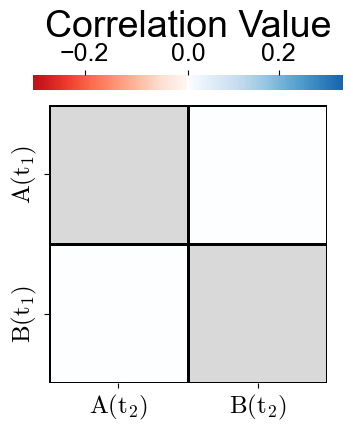

/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing: filtered_directional_correlation_type_A_rep_B


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_rep_B_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_rep_B_with_gridlines.svg


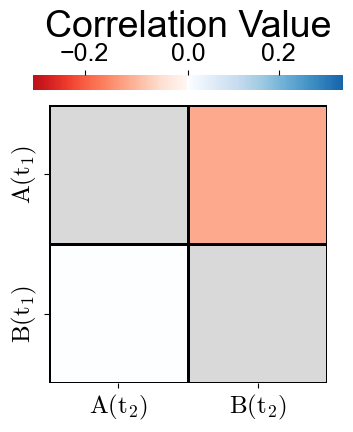

/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing: filtered_directional_correlation_type_A_rep_B_B_rep_A


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_rep_B_B_rep_A_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_rep_B_B_rep_A_with_gridlines.svg


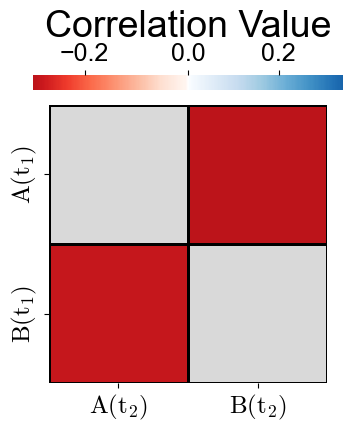

/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing: filtered_directional_correlation_type_A_rep_B_B_to_A


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_rep_B_B_to_A_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_rep_B_B_to_A_with_gridlines.svg


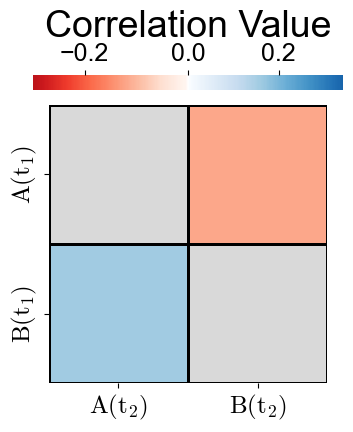

/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing: filtered_directional_correlation_type_A_to_B


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_to_B_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_to_B_with_gridlines.svg


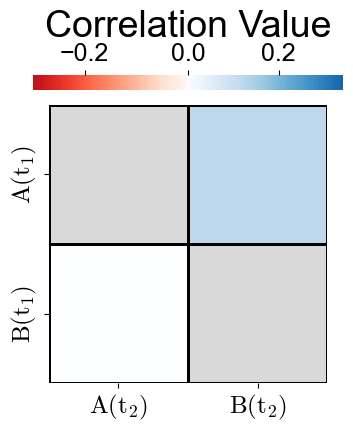

/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing: filtered_directional_correlation_type_A_to_B_B_to_A


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_to_B_B_to_A_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_A_to_B_B_to_A_with_gridlines.svg


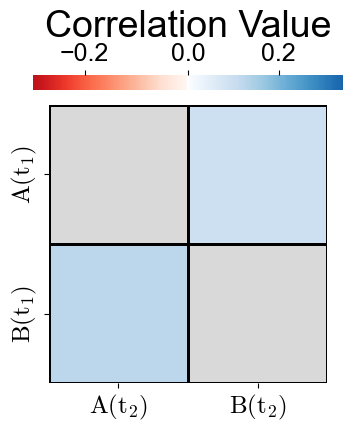

/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing: filtered_directional_correlation_type_five_gene_linear_cascade


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_five_gene_linear_cascade_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_five_gene_linear_cascade_with_gridlines.svg


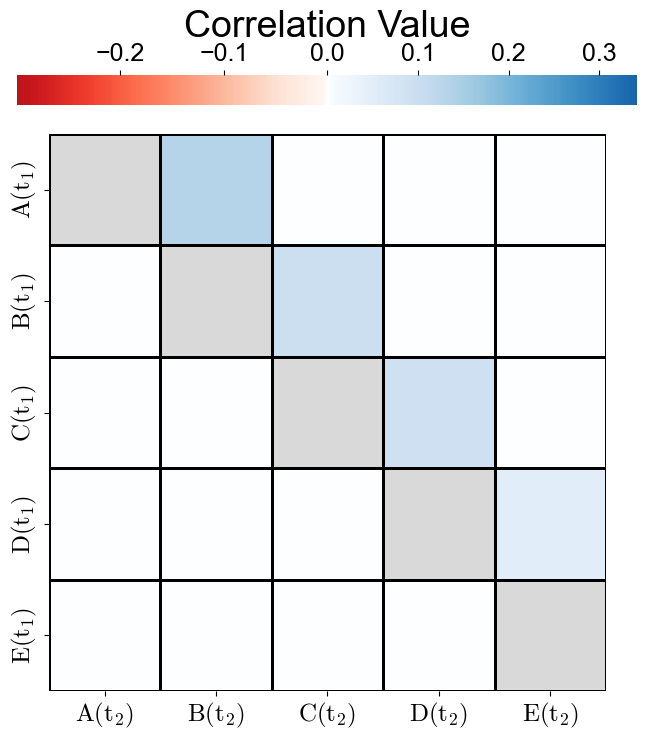

/tmp/ipykernel_284665/2863353439.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing: filtered_directional_correlation_type_five_gene_linear_cascade_random_ctrl


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_five_gene_linear_cascade_random_ctrl_correlation_with_gridlines.png
Saved SVG: /home/keerthm/twinfer/plots_3/filtered_directional_correlation_type_five_gene_linear_cascade_random_ctrl_with_gridlines.svg


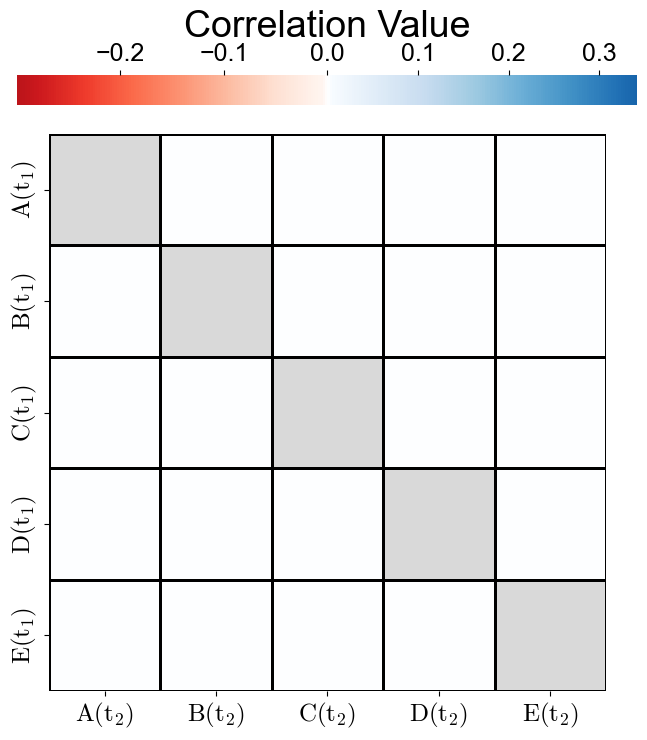

Individual plots generated successfully!


In [15]:
# try:
plot_all_correlations_common_scale(
        path_to_plot_data,
        path_to_plots=f"{path_to_plots}/",
        use_symmetric_scale=True,
        matrix_type="correlation"
    )
print("Individual plots generated successfully!")

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


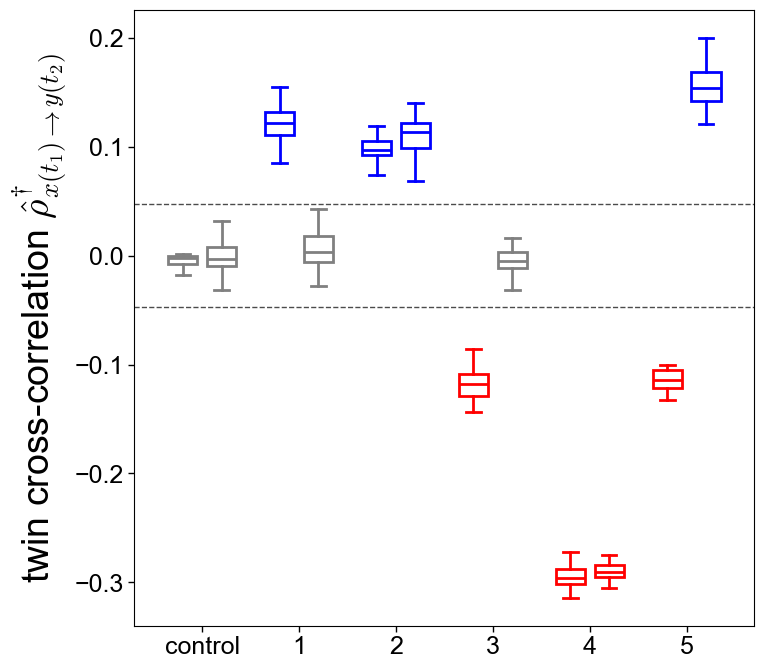

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


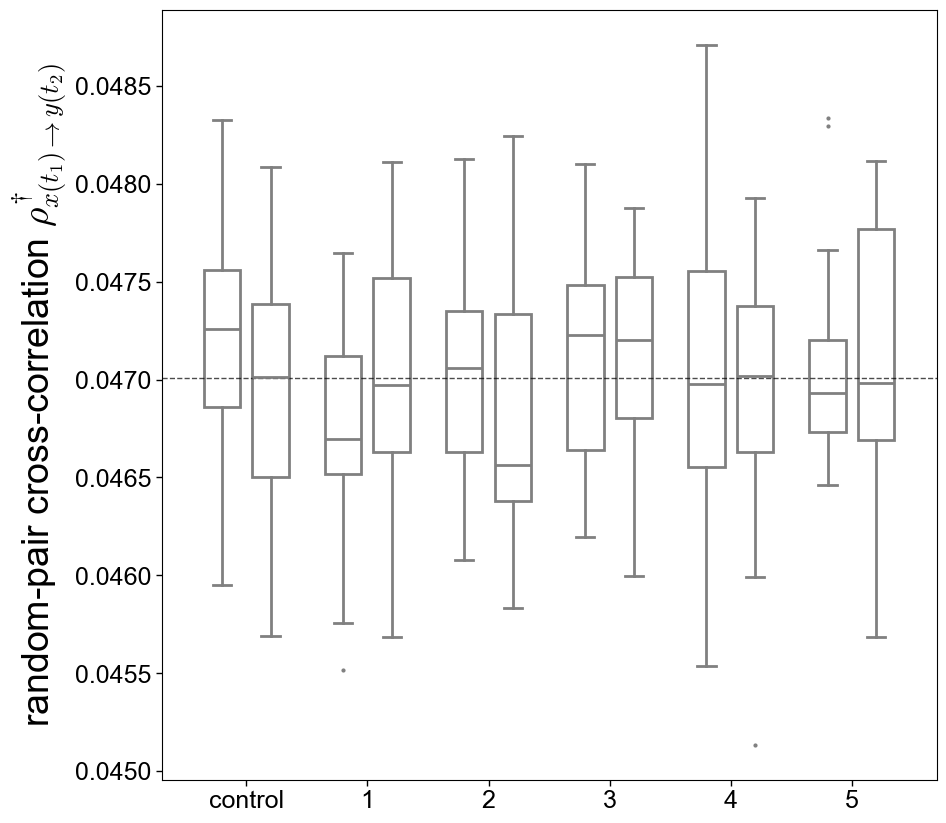

Saved plots to /home/keerthm/twinfer/plots_3/:
1. correlations_with_thresholds.pdf
2. threshold_boxplots.pdf


In [20]:
df_results = pd.read_csv(f"{path_to_plot_data}/box_plot_data.csv")
create_box_plot_and_save(df_results, path_to_plots) 

## Five gene cascade plot

### Twin plot

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Saved PNG: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3/five_gene_cascade_twin.png
Saved SVG: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3/five_gene_cascade_twin.svg


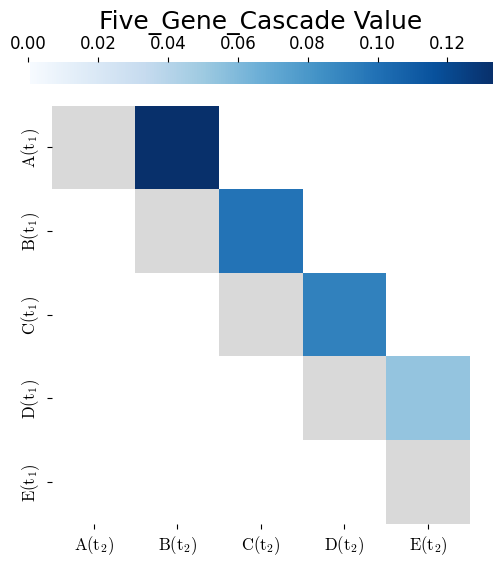

In [26]:
import matplotlib.colors as mcolors
import seaborn as sns
file_path = f"{path_to_plot_data}/filtered_directional_correlation_type_five_gene_linear_cascade.csv"
df = pd.read_csv(file_path, index_col=0)
data_matrix = df.to_numpy(float)
# 1. diagonal = gray
matrix_type = "five_gene_cascade"
# 2. mask the diagonal
data_matrix = df.to_numpy(float)
masked_matrix = np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])
from matplotlib.colors import ListedColormap

cmap = make_reds_blues_colormap()

vmin, vmax = min(0.0, np.nanmin(df.values.flatten())), np.nanmax(df.values.flatten())
# norm = TwoSlopeNorm(vmin=vmin, vmax=vmax)
# center = 0
cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    data_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    # norm=norm,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal', 'label': f'{matrix_type.title()} Value'},
    linewidths=1.0,
    linecolor="black",
    # center=center
)

# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.xaxis.tick_top()
heatmap_ax.set_xticklabels(convert_gene_labels(df.columns, 'x'))
heatmap_ax.set_yticklabels(convert_gene_labels(df.index, 'y'))
# --- transparent background ---
plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
# --- save ---
if path_to_plot_data:
    out = Path(path_to_plot_data)
    out.mkdir(parents=True, exist_ok=True)
    png_path = out / f"{matrix_type}_twin.png"
    svg_path = out / f"{matrix_type}_twin.svg"
    pdf_path = out / f"{matrix_type}_twin.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
else:
    plt.show()

### Random control

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Saved PNG: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3/five_gene_cascade_random.png
Saved SVG: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3/five_gene_cascade_random.svg


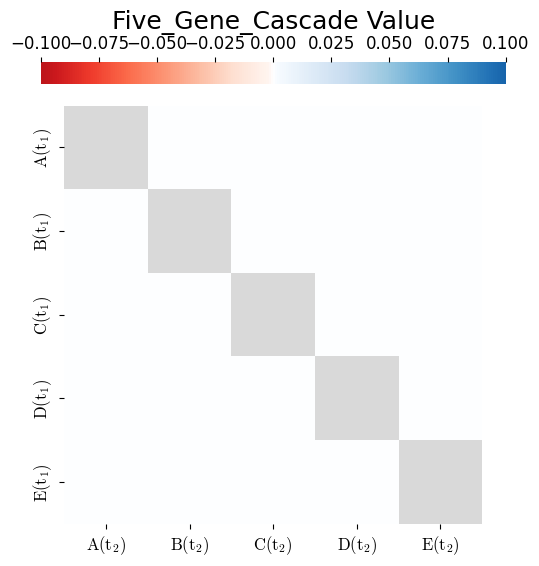

In [22]:
import matplotlib.colors as mcolors
import seaborn as sns
file_path = f"{path_to_plot_data}/filtered_directional_correlation_type_five_gene_linear_cascade_random_ctrl.csv"
df = pd.read_csv(file_path, index_col=0)
data_matrix = df.to_numpy(float)
# 1. diagonal = gray
matrix_type = "five_gene_cascade"
# 2. mask the diagonal
data_matrix = df.to_numpy(float)
masked_matrix = np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])
cmap = make_reds_blues_colormap()
vmin, vmax = min(0.0, np.nanmin(df.values.flatten())), np.nanmax(df.values.flatten())
# norm = TwoSlopeNorm(vmin=vmin, vmax=vmax)
# center = 0
cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    data_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    # norm=norm,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal', 'label': f'{matrix_type.title()} Value'},
    linewidths=1.0,
    linecolor="black",
    # center=center
)

# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.xaxis.tick_top()
heatmap_ax.set_xticklabels(convert_gene_labels(df.columns, 'x'))
heatmap_ax.set_yticklabels(convert_gene_labels(df.index, 'y'))
# --- transparent background ---
plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
# --- save ---
if path_to_plot_data:
    out = Path(path_to_plot_data)
    out.mkdir(parents=True, exist_ok=True)
    png_path = out / f"{matrix_type}_random.png"
    svg_path = out / f"{matrix_type}_random.svg"
    pdf_path = out / f"{matrix_type}_random.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
else:
    plt.show()